In [2]:
import torch
from torch import nn
from d2l import torch as d2l

In [3]:
batch_size = 256
train_iter, test_iter = d2l.load_data_fashion_mnist(batch_size)  # 分割数据集

In [4]:
num_inputs,num_outputs,num_hiddens = 784,10,256  # 定义输入层 输出层 隐藏层
W1 = nn.Parameter(torch.randn(num_inputs,num_hiddens,requires_grad=True)*0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens,requires_grad=True))
W2 = nn.Parameter(torch.randn(num_hiddens,num_outputs,requires_grad=True)*0.01)
b2 = nn.Parameter(torch.zeros(num_outputs,requires_grad=True))

params = [W1,b1,W2,b2]  # 设置参数 两个方程

In [5]:
def relu(x):
    a = torch.zeros_like(x)
    return torch.maximum(a, x)  # 激活函数relu的定义  等于nn.relu(x)

In [6]:
def net(x):
    x = x.reshape((-1,num_inputs))  # 拉平
    H = relu(x@W1 + b1)  # 矩阵乘法torch.matmul(X, W)等价X@W
    return H@W2 + b2

In [7]:
loss = nn.CrossEntropyLoss()  # 交叉熵损失函数

In [8]:
num_epochs, lr= 10, 0.1
updater = torch.optim.SGD(params, lr=lr)  # 随机梯度下降
d2l.train_ch3(net,train_iter, test_iter, loss, num_epochs, updater)

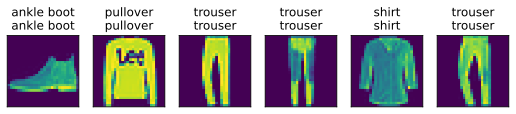

In [9]:
d2l.predict_ch3(net,test_iter)  # 开始预测